# 📊 Marketing Funnel & Conversion Analysis

## FUTURE_DS_03 – Future Intern Data Science Internship

### 📌 Project Overview

Marketing funnel analysis helps organizations understand how potential customers progress through different stages of the sales funnel and identify where the highest customer drop-offs occur.

This project analyzes a real-world marketing campaign dataset to evaluate campaign performance, customer conversion rates, lead quality, and opportunities for improving marketing effectiveness.

---

### 🎯 Objectives

- Analyze marketing campaign performance
- Measure customer conversion rates
- Identify major funnel drop-off points
- Compare campaign performance across customer segments
- Generate actionable business recommendations
- Build an interactive Power BI dashboard

---

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Microsoft Power BI
- Power Query
- DAX

# Import Libraries

In [3]:
# Marketing Funnel Analysis

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Load Dataset

In [4]:
df = pd.read_csv(
    "bank-additional-full.csv",
    sep=";"
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
print("DATASET OVERVIEW")

print("Shape :", df.shape)

print("\nColumns")

print(df.columns.tolist())

DATASET OVERVIEW
Shape : (41188, 21)

Columns
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


# Data Cleaning

In [10]:
print("DUPLICATE RECORDS")

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

DUPLICATE RECORDS
Duplicate Rows : 12


In [11]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates")
print(df.shape)

Shape After Removing Duplicates
(41176, 21)


In [12]:
print("DATASET SUMMARY")

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nData Types")

print(df.dtypes.value_counts())

DATASET SUMMARY
Rows : 41176
Columns : 21

Data Types
object     11
int64       5
float64     5
Name: count, dtype: int64


In [13]:
print(df["y"].value_counts())

print("\nPercentage")

print((df["y"].value_counts(normalize=True)*100).round(2))

y
no     36537
yes     4639
Name: count, dtype: int64

Percentage
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


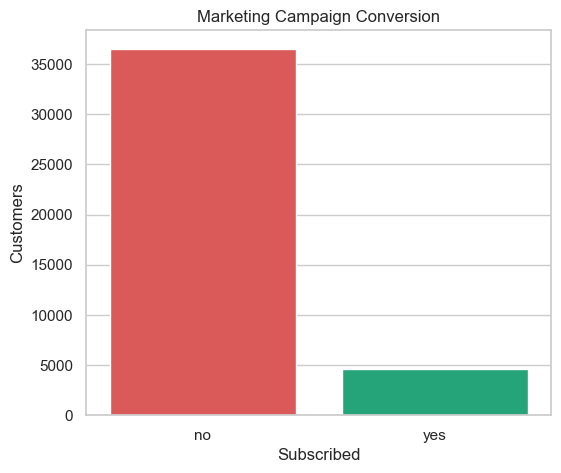

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="y",
    palette=["#EF4444","#10B981"]
)

plt.title("Marketing Campaign Conversion")

plt.xlabel("Subscribed")

plt.ylabel("Customers")

plt.show()

In [15]:
total_contacts = len(df)

converted = (df["y"]=="yes").sum()

not_converted = (df["y"]=="no").sum()

conversion_rate = round(converted/total_contacts*100,2)

print("Total Contacts :", total_contacts)

print("Converted Customers :", converted)

print("Not Converted :", not_converted)

print("Conversion Rate :", conversion_rate,"%")

Total Contacts : 41176
Converted Customers : 4639
Not Converted : 36537
Conversion Rate : 11.27 %


In [16]:
funnel = pd.DataFrame({

    "Stage":[

        "Campaign Contacts",
        "Converted Customers"

    ],

    "Count":[

        total_contacts,
        converted

    ]

})

funnel

,Stage,Count
0,Campaign Contacts,41176
1,Converted Customers,4639


In [17]:
df.to_csv(
    "Marketing_Funnel_Cleaned.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


# Exploratory Data Analysis (EDA)

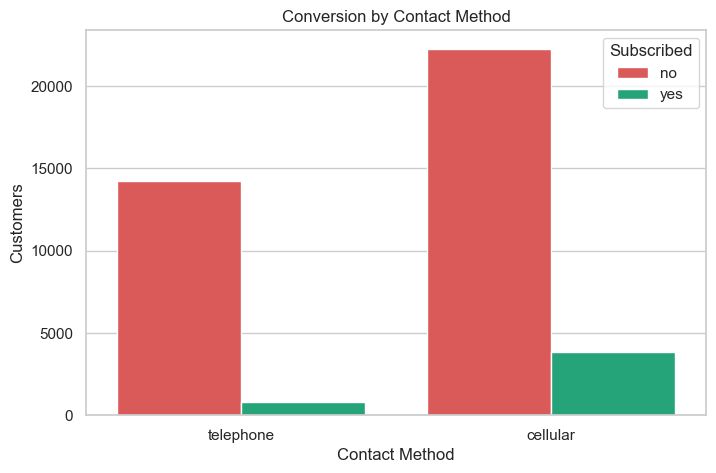

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="contact",
    hue="y",
    palette=["#EF4444", "#10B981"]
)

plt.title("Conversion by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Customers")
plt.legend(title="Subscribed")

plt.show()

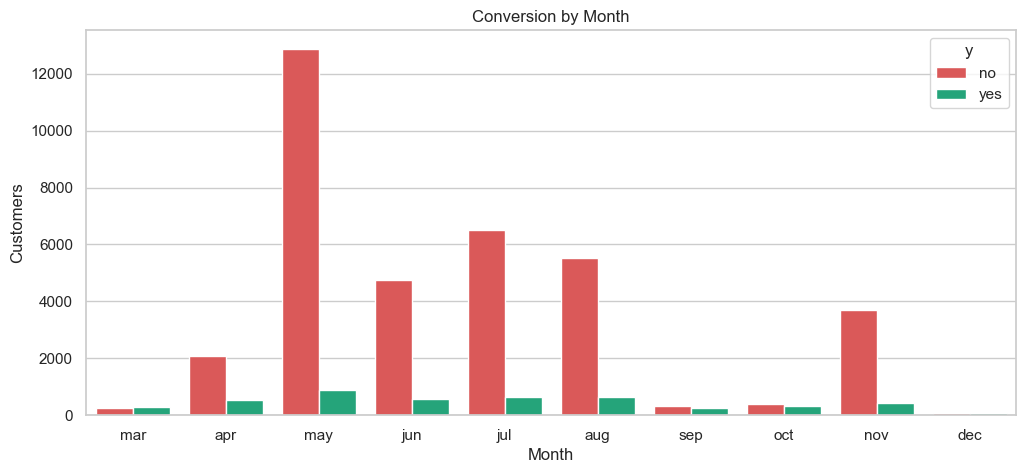

In [19]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="month",
    hue="y",
    order=[
        "mar","apr","may","jun",
        "jul","aug","sep","oct",
        "nov","dec"
    ],
    palette=["#EF4444","#10B981"]
)

plt.title("Conversion by Month")
plt.xlabel("Month")
plt.ylabel("Customers")

plt.show()

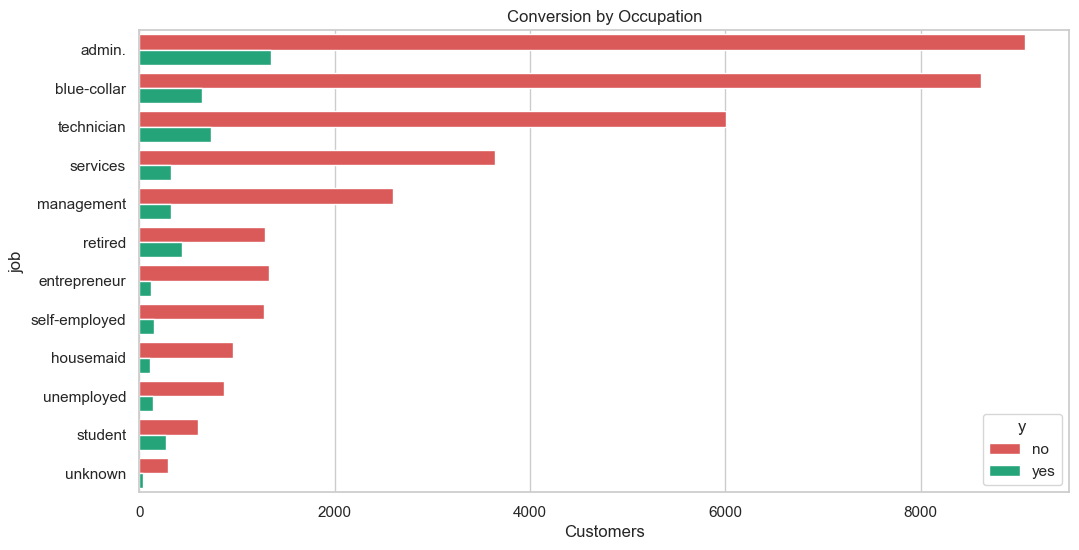

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="job",
    hue="y",
    order=df["job"].value_counts().index,
    palette=["#EF4444","#10B981"]
)

plt.title("Conversion by Occupation")
plt.xlabel("Customers")

plt.show()

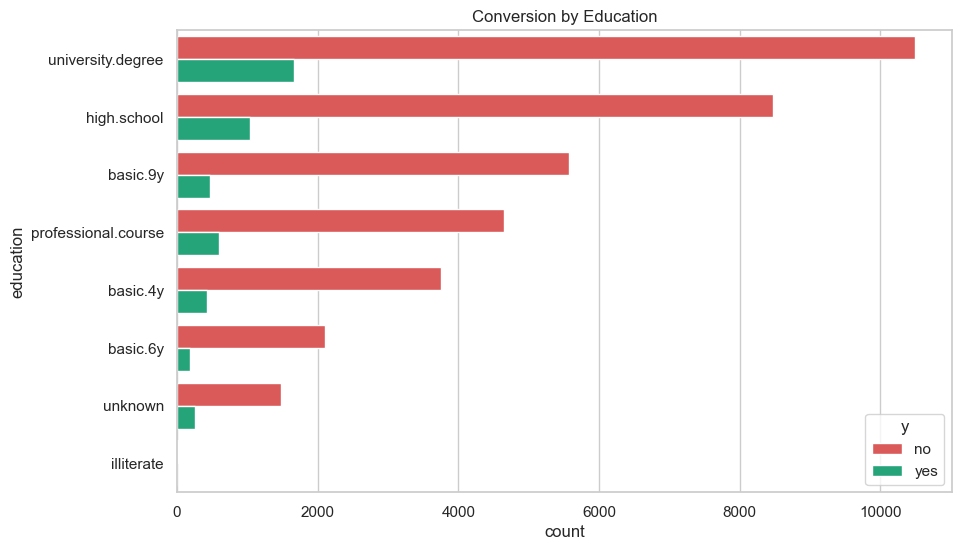

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="education",
    hue="y",
    order=df["education"].value_counts().index,
    palette=["#EF4444","#10B981"]
)

plt.title("Conversion by Education")

plt.show()

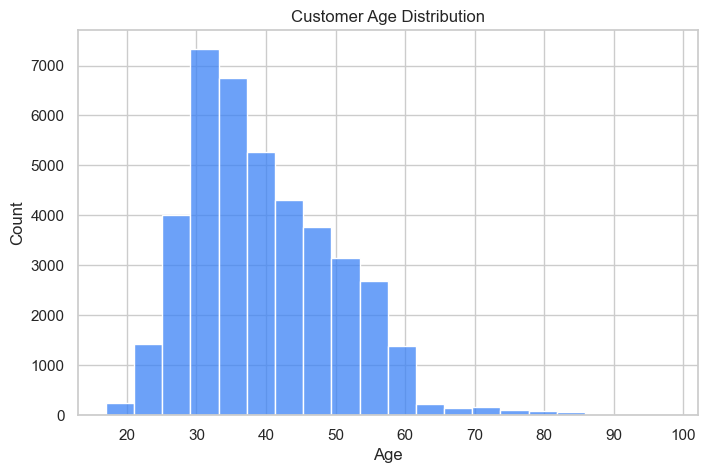

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    color="#3B82F6"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")

plt.show()

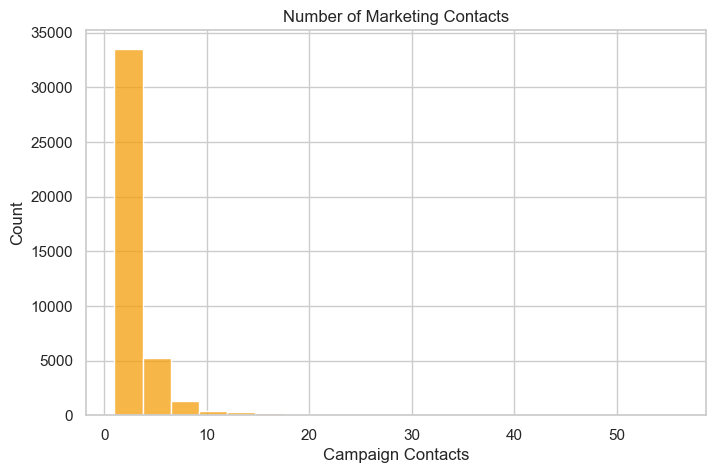

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["campaign"],
    bins=20,
    color="#F59E0B"
)

plt.title("Number of Marketing Contacts")
plt.xlabel("Campaign Contacts")

plt.show()

# Feature Engineering

In [24]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

df["Age_Group"].value_counts()

Age_Group
26-35    14844
36-45    12839
46-55     8247
56-65     2963
18-25     1660
65+        618
Name: count, dtype: int64

In [25]:
df["Campaign_Category"] = pd.cut(
    df["campaign"],
    bins=[0, 2, 5, 10, 60],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["Campaign_Category"].value_counts()

Campaign_Category
Low          28202
Medium        9589
High          2516
Very High      869
Name: count, dtype: int64

In [26]:
df["Previous_Contact"] = np.where(
    df["previous"] == 0,
    "No Previous Contact",
    "Previously Contacted"
)

df["Previous_Contact"].value_counts()

Previous_Contact
No Previous Contact     35551
Previously Contacted     5625
Name: count, dtype: int64

In [27]:
df["Conversion"] = df["y"].map({
    "yes": "Converted",
    "no": "Not Converted"
})

df["Conversion"].value_counts()

Conversion
Not Converted    36537
Converted         4639
Name: count, dtype: int64

In [28]:
df.to_csv(
    "Marketing_Funnel_Final.csv",
    index=False
)

print("Final Dataset Saved Successfully!")

Final Dataset Saved Successfully!
